# 📉 Customer Churn Prediction

**Dataset**: IBM Telco Customer Churn — 7,043 rows × 21 columns  
**Target**: `Churn` (Yes / No) → Binary Classification  

---
## Section 1 — Data Exploration
## Section 2 — Data Cleaning & Preprocessing

---
## Section 1 — Data Exploration

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RAW_DATA_PATH, TARGET_COL, NUMERICAL_COLS, PLOT_STYLE, FIG_DPI, COLOR_CHURN, IMAGES_DIR

pd.set_option('display.max_columns', 30)
plt.style.use(PLOT_STYLE)
print('Libraries ready')

Libraries ready


In [2]:
# Load raw dataset
df = pd.read_csv(RAW_DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Statistical summary — numerical
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Statistical summary — categorical
df.describe(include='object')

C:\Users\Voval\AppData\Local\Temp\ipykernel_13624\2806746979.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [6]:
# Standard null check
print('NaN counts:')
print(df.isnull().sum())

# Hidden blank strings (TotalCharges issue)
print('\nHidden blank strings in object columns:')
for col in df.select_dtypes(include='object').columns:
    n = (df[col].str.strip() == '').sum()
    if n > 0:
        print(f'  [{col}]: {n} blank value(s)')

NaN counts:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Hidden blank strings in object columns:
  [TotalCharges]: 11 blank value(s)


C:\Users\Voval\AppData\Local\Temp\ipykernel_13624\2165259943.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [7]:
# Duplicate check
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Unique customerIDs: {df["customerID"].nunique()} (total rows: {len(df)})')

Duplicate rows: 0
Unique customerIDs: 7043 (total rows: 7043)


In [8]:
# Target variable distribution
print(df[TARGET_COL].value_counts())
print(df[TARGET_COL].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


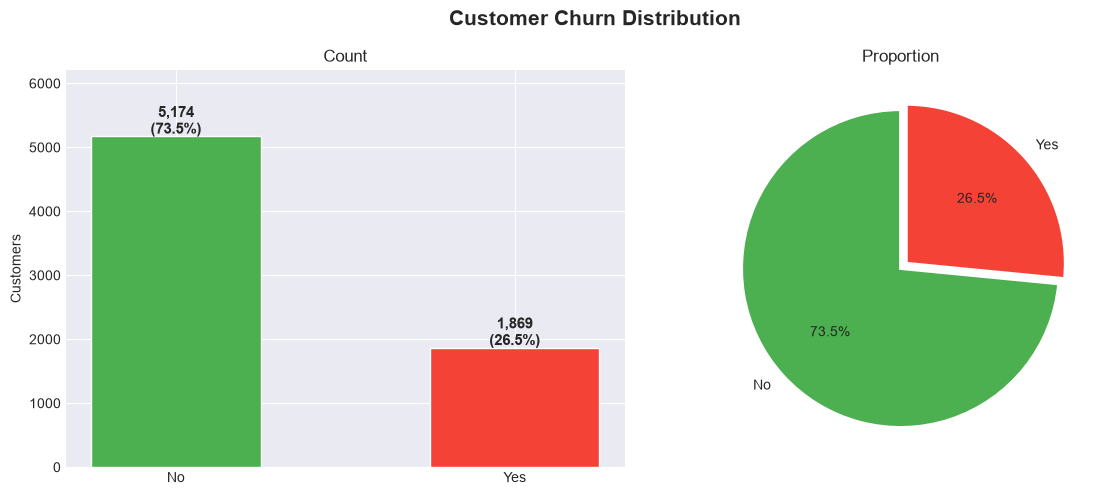

In [9]:
# Churn distribution — bar + pie
churn_counts = df[TARGET_COL].value_counts()
churn_pct    = df[TARGET_COL].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Customer Churn Distribution', fontsize=15, fontweight='bold')
colors = [COLOR_CHURN['No'], COLOR_CHURN['Yes']]

# Bar
bars = axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Count'); axes[0].set_ylabel('Customers')
for bar, (lbl, cnt, pct) in zip(bars, zip(churn_counts.index, churn_counts.values, churn_pct.values)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{cnt:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, churn_counts.max() * 1.2)

# Pie
axes[1].pie(churn_counts.values, labels=churn_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0, 0.05),
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'churn_distribution.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

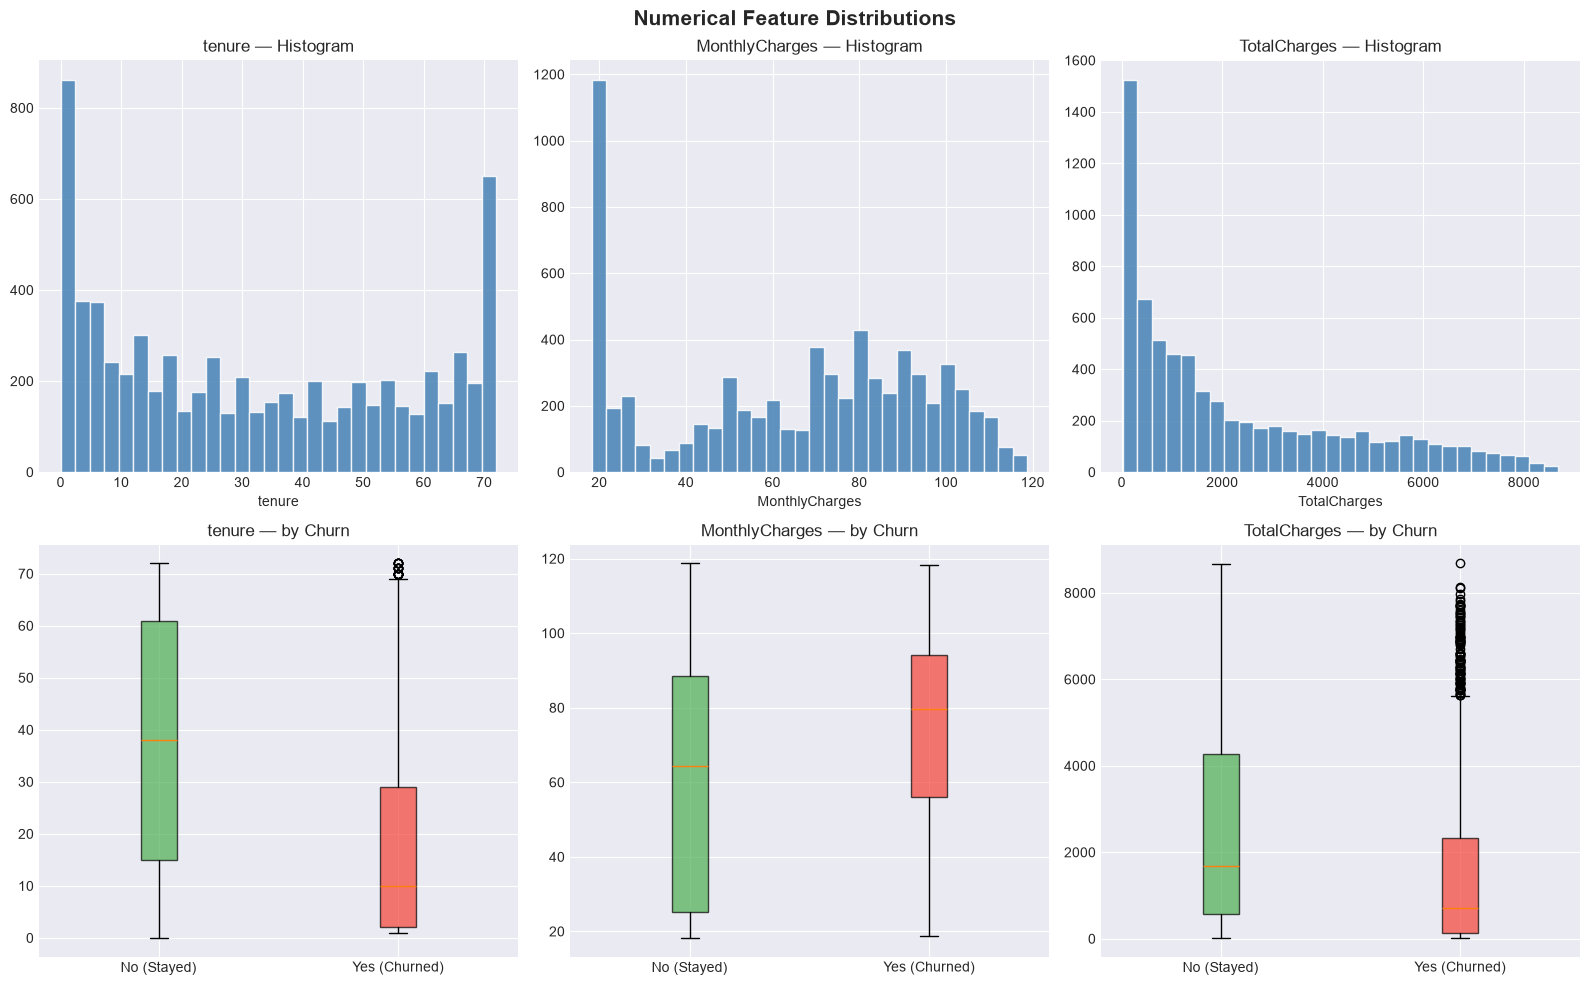

In [10]:
# Numerical features — histograms & boxplots by Churn
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Numerical Feature Distributions', fontsize=15, fontweight='bold')

for i, col in enumerate(NUMERICAL_COLS):
    col_data = pd.to_numeric(df[col], errors='coerce').dropna()

    # Histogram
    axes[0][i].hist(col_data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0][i].set_title(f'{col} — Histogram'); axes[0][i].set_xlabel(col)

    # Boxplot by Churn
    tmp = df[['Churn', col]].copy()
    tmp[col] = pd.to_numeric(tmp[col], errors='coerce')
    groups = [tmp[tmp['Churn'] == lbl][col].dropna() for lbl in ['No', 'Yes']]
    bp = axes[1][i].boxplot(groups, tick_labels=['No (Stayed)', 'Yes (Churned)'], patch_artist=True)
    for patch, c in zip(bp['boxes'], [COLOR_CHURN['No'], COLOR_CHURN['Yes']]):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    axes[1][i].set_title(f'{col} — by Churn')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'numerical_distributions.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

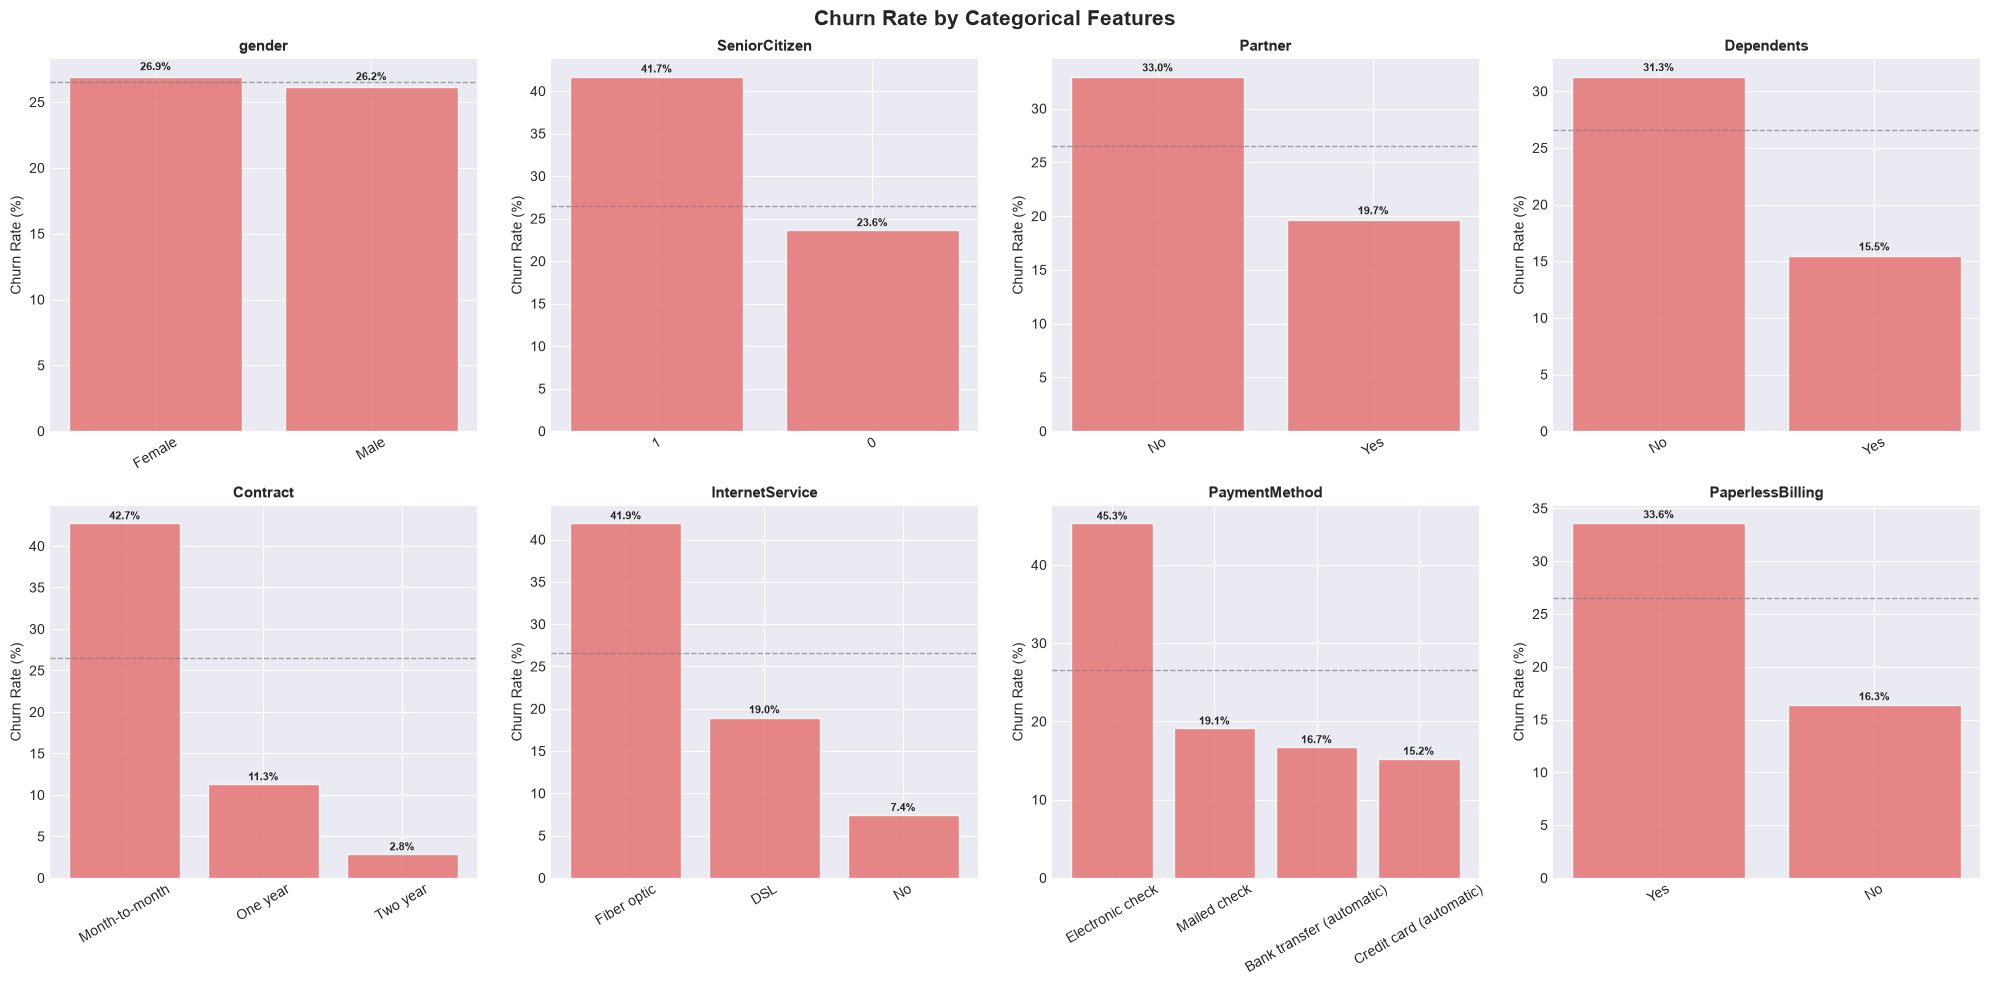

In [11]:
cols_to_plot = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                'Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Churn Rate by Categorical Features', fontsize=15, fontweight='bold')

# df is loaded from raw data in Section 1 — Churn is 'Yes'/'No' string
# Map to 0/1 temporarily for computing churn rate
churn_numeric = df[TARGET_COL].map({'No': 0, 'Yes': 1})

for idx, col in enumerate(cols_to_plot):
    ax = axes[idx // 4][idx % 4]
    churn_rate = churn_numeric.groupby(df[col]).mean().sort_values(ascending=False) * 100
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values,
                  color='#E57373', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(y=churn_numeric.mean() * 100, color='gray',
               linestyle='--', linewidth=1, alpha=0.7)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'categorical_churn_rates.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()


**Key Findings — Exploration**
- 7,043 rows × 21 columns, no true NaN values
- `TotalCharges` stored as string with 11 hidden blank rows (tenure=0 customers)
- Class imbalance: 73.5% stayed / 26.5% churned → use F1 & ROC-AUC as metrics
- Top signals: `Contract` type, `InternetService`, `tenure`, `MonthlyCharges`, `PaymentMethod`

---
## Section 2 — Data Cleaning & Preprocessing

In [12]:
from src.preprocessing import load_raw_data, clean_data, get_cleaning_report
from src.config import CLEANED_DATA_PATH

df_raw = load_raw_data(RAW_DATA_PATH)

✅ Loaded raw data: 7,043 rows × 21 columns


In [13]:
# Inspect the 11 blank TotalCharges rows (tenure=0 customers, never billed)
problematic = df_raw[df_raw['TotalCharges'].str.strip() == '']
print(f'Rows with blank TotalCharges: {len(problematic)}')
problematic[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].reset_index(drop=True)

Rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
0,4472-LVYGI,0,52.55,,No
1,3115-CZMZD,0,20.25,,No
2,5709-LVOEQ,0,80.85,,No
3,4367-NUYAO,0,25.75,,No
4,1371-DWPAZ,0,56.05,,No
5,7644-OMVMY,0,19.85,,No
6,3213-VVOLG,0,25.35,,No
7,2520-SGTTA,0,20.00,,No
8,2923-ARZLG,0,19.70,,No
9,4075-WKNIU,0,73.35,,No


In [14]:
# Run full cleaning pipeline
# Steps: fix TotalCharges → drop customerID → remove duplicates → validate SeniorCitizen → encode Churn
df_clean = clean_data(df_raw, id_col='customerID', target_col='Churn', encode_target_flag=True)

  🧹 Running Cleaning Pipeline
  ✔ TotalCharges: 11 blank rows imputed with median = 1397.47
  ✔ TotalCharges dtype → float64
  ✔ Dropped column: 'customerID'
  ✔ Removed 22 duplicate row(s)
  ✔ SeniorCitizen: confirmed as binary int (0=No, 1=Yes)
  ✔ 'Churn' encoded: Yes→1, No→0
    Distribution: {0: 5164, 1: 1857}
  ✅ Cleaning complete! Shape: 7,021 rows × 20 cols


In [15]:
# Before vs After report
_ = get_cleaning_report(df_raw, df_clean)

📋 Cleaning Report
----------------------------------------
  Rows : 7,043 → 7,021  (removed: 22)
  Cols : 21 → 20  (removed: 1)

  Dtype changes:
      Column Before   After
TotalCharges    str float64
       Churn    str   int64

  ✅ No null values remain in cleaned dataset


In [16]:
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


C:\Users\Voval\AppData\Local\Temp\ipykernel_13624\1729692605.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Voval\AppData\Local\Temp\ipykernel_13624\1729692605.py:32: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.savefig(IMAGES_DIR / 'cleaning_verification.png', dpi=FIG_DPI, bbox_inches='tight')


d:\Customer Churn Prediction project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


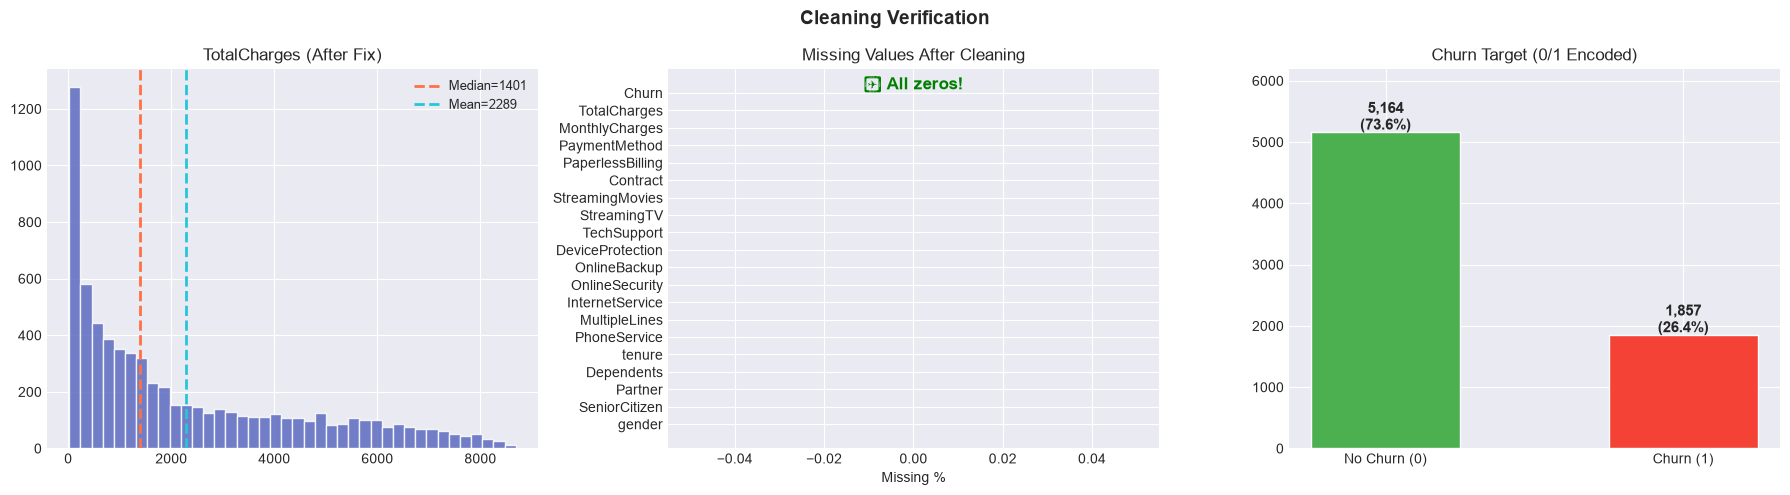

In [17]:
# Verify cleaning — 3-panel plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Cleaning Verification', fontsize=14, fontweight='bold')

# 1. TotalCharges distribution after fix
axes[0].hist(df_clean['TotalCharges'], bins=40, color='#5C6BC0', edgecolor='white', alpha=0.85)
axes[0].axvline(df_clean['TotalCharges'].median(), color='#FF7043', linewidth=2, linestyle='--',
                label=f'Median={df_clean["TotalCharges"].median():.0f}')
axes[0].axvline(df_clean['TotalCharges'].mean(), color='#26C6DA', linewidth=2, linestyle='--',
                label=f'Mean={df_clean["TotalCharges"].mean():.0f}')
axes[0].set_title('TotalCharges (After Fix)'); axes[0].legend(fontsize=9)

# 2. Null heatmap
null_pct = (df_clean.isnull().sum() / len(df_clean) * 100).reset_index()
null_pct.columns = ['Column', 'Null%']
bar_colors = ['#EF5350' if v > 0 else '#66BB6A' for v in null_pct['Null%']]
axes[1].barh(null_pct['Column'], null_pct['Null%'], color=bar_colors)
axes[1].set_title('Missing Values After Cleaning'); axes[1].set_xlabel('Missing %')
axes[1].text(0.5, 0.98, '✅ All zeros!', transform=axes[1].transAxes,
             ha='center', va='top', fontsize=12, color='green', fontweight='bold')

# 3. Encoded target
cc = df_clean[TARGET_COL].value_counts().sort_index()
bars = axes[2].bar(['No Churn (0)', 'Churn (1)'], cc.values,
                   color=[COLOR_CHURN['No'], COLOR_CHURN['Yes']], edgecolor='white', width=0.5)
for bar, cnt in zip(bars, cc.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{cnt:,}\n({cnt/len(df_clean)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[2].set_title('Churn Target (0/1 Encoded)'); axes[2].set_ylim(0, cc.max() * 1.2)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'cleaning_verification.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

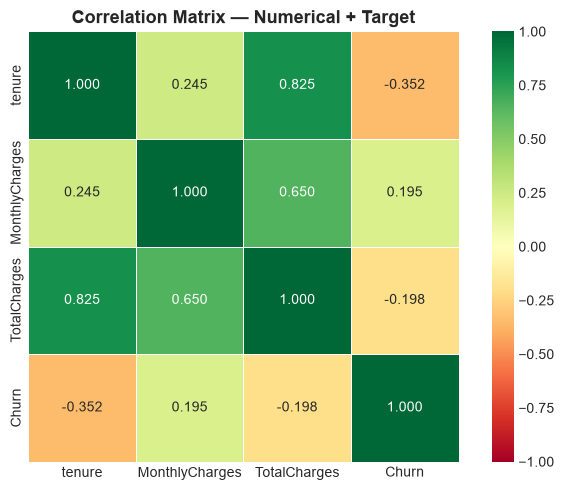


Correlation with Churn:
tenure           -0.351508
TotalCharges     -0.197911
MonthlyCharges    0.194508
Name: Churn, dtype: float64


In [18]:
# Correlation heatmap — numerical features + target
corr = df_clean[NUMERICAL_COLS + [TARGET_COL]].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, linewidths=0.5, square=True, ax=ax)
ax.set_title('Correlation Matrix — Numerical + Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'correlation_heatmap.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

print('\nCorrelation with Churn:')
print(corr[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False))

In [19]:
# Save cleaned dataset
df_clean.to_csv(CLEANED_DATA_PATH, index=False)
print(f'Saved → {CLEANED_DATA_PATH}')
print(f'Shape : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print(f'Nulls : {df_clean.isnull().sum().sum()}')

Saved → D:\Customer Churn Prediction project\data\processed\cleaned_data.csv
Shape : 7,021 rows × 20 columns
Nulls : 0


**Key Findings — Cleaning**
- `TotalCharges`: converted to float, 11 blank rows imputed with median (right-skewed → median preferred over mean)
- `customerID`: dropped (identifier, no predictive signal)
- Duplicates: 0 found
- `Churn`: encoded Yes→1, No→0
- Final shape: 7,043 rows × 20 columns, 0 nulls
- `TotalCharges` and `tenure` are highly correlated → will engineer `AvgMonthlySpend` in Feature Engineering

---
## Section 3 — Exploratory Data Analysis (EDA) Visualizations

Deep-dive plots to understand how each feature relates to churn.  
All plots saved to `images/`. Key findings summarised in `reports/eda_report.md`.

**Plots covered:**
1. Tenure distribution by Churn (KDE + Violin)
2. Monthly & Total Charges by Churn (Boxplot + KDE)
3. Senior Citizen vs Churn (Stacked Bar)
4. Contract Type vs Churn (Stacked + Rate)
5. Internet Service vs Churn
6. Payment Method vs Churn
7. Service bundle heatmap (churn rate per service)
8. Pairplot — numerical features coloured by Churn

In [20]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import (CLEANED_DATA_PATH, RAW_DATA_PATH, TARGET_COL,
                        NUMERICAL_COLS, PLOT_STYLE, FIG_DPI, COLOR_CHURN,
                        IMAGES_DIR, REPORTS_DIR)
from src.preprocessing import load_raw_data, clean_data

plt.style.use(PLOT_STYLE)

# df: numerically encoded (used for correlation, pairplot, boxplots)
df = pd.read_csv(CLEANED_DATA_PATH)

# df_str: original string labels for categorical plots
# clean_data keeps string labels when encode_target_flag=True only encodes Churn
df_raw = load_raw_data(RAW_DATA_PATH)
df_str = clean_data(df_raw, encode_target_flag=True)

print(f'df shape      : {df.shape}')
print(f'df_str shape  : {df_str.shape}')
print(f'Churn dist    : {df[TARGET_COL].value_counts().to_dict()}')


✅ Loaded raw data: 7,043 rows × 21 columns
  🧹 Running Cleaning Pipeline
  ✔ TotalCharges: 11 blank rows imputed with median = 1397.47
  ✔ TotalCharges dtype → float64
  ✔ Dropped column: 'customerID'
  ✔ Removed 22 duplicate row(s)
  ✔ SeniorCitizen: confirmed as binary int (0=No, 1=Yes)
  ✔ 'Churn' encoded: Yes→1, No→0
    Distribution: {0: 5164, 1: 1857}
  ✅ Cleaning complete! Shape: 7,021 rows × 20 cols
df shape      : (7021, 20)
df_str shape  : (7021, 20)
Churn dist    : {0: 5164, 1: 1857}


### Plot 1 — Tenure Distribution by Churn (KDE + Violin)

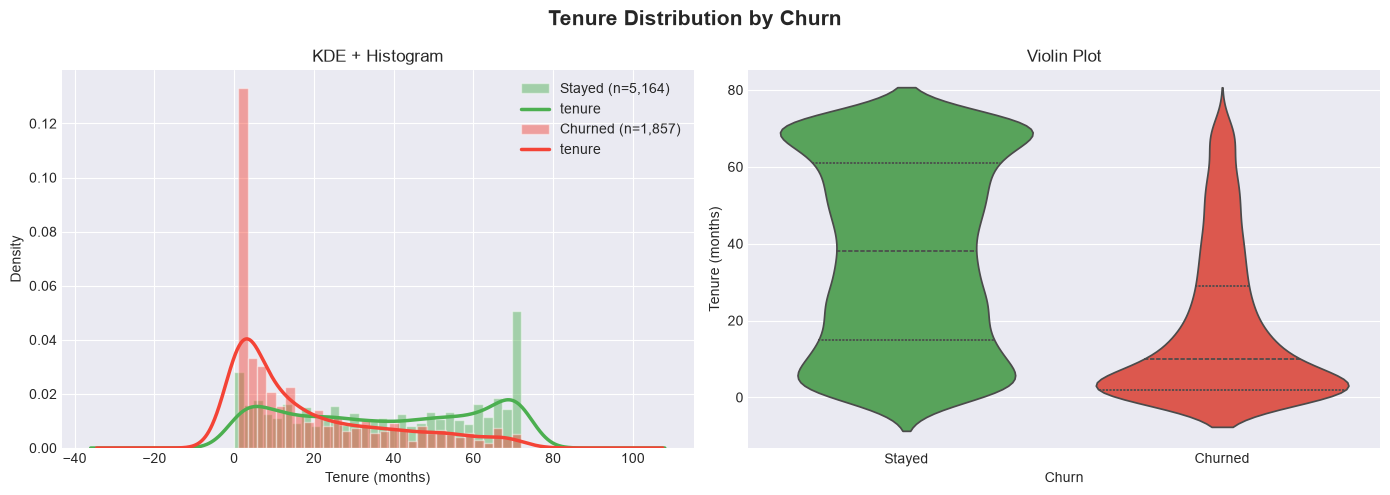

Median tenure Stayed : 38.0
Median tenure Churned: 10.0


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tenure Distribution by Churn', fontsize=15, fontweight='bold')

for lbl, color, label in [(0, COLOR_CHURN['No'], 'Stayed'), (1, COLOR_CHURN['Yes'], 'Churned')]:
    sub = df[df[TARGET_COL] == lbl]['tenure']
    axes[0].hist(sub, bins=30, alpha=0.45, color=color, edgecolor='white',
                 density=True, label=f'{label} (n={len(sub):,})')
    sub.plot.kde(ax=axes[0], color=color, linewidth=2.5)
axes[0].set_title('KDE + Histogram')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Density')
axes[0].legend()

df['Churn_lbl'] = df[TARGET_COL].map({0: 'Stayed', 1: 'Churned'})
sns.violinplot(
    data=df, x='Churn_lbl', y='tenure', hue='Churn_lbl',
    palette={'Stayed': COLOR_CHURN['No'], 'Churned': COLOR_CHURN['Yes']},
    inner='quartile', legend=False, ax=axes[1]
)
axes[1].set_title('Violin Plot')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tenure (months)')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'eda_tenure_by_churn.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()
df.drop(columns=['Churn_lbl'], inplace=True)
print('Median tenure Stayed :', df[df[TARGET_COL]==0]['tenure'].median())
print('Median tenure Churned:', df[df[TARGET_COL]==1]['tenure'].median())


### Plot 2 — Monthly & Total Charges by Churn

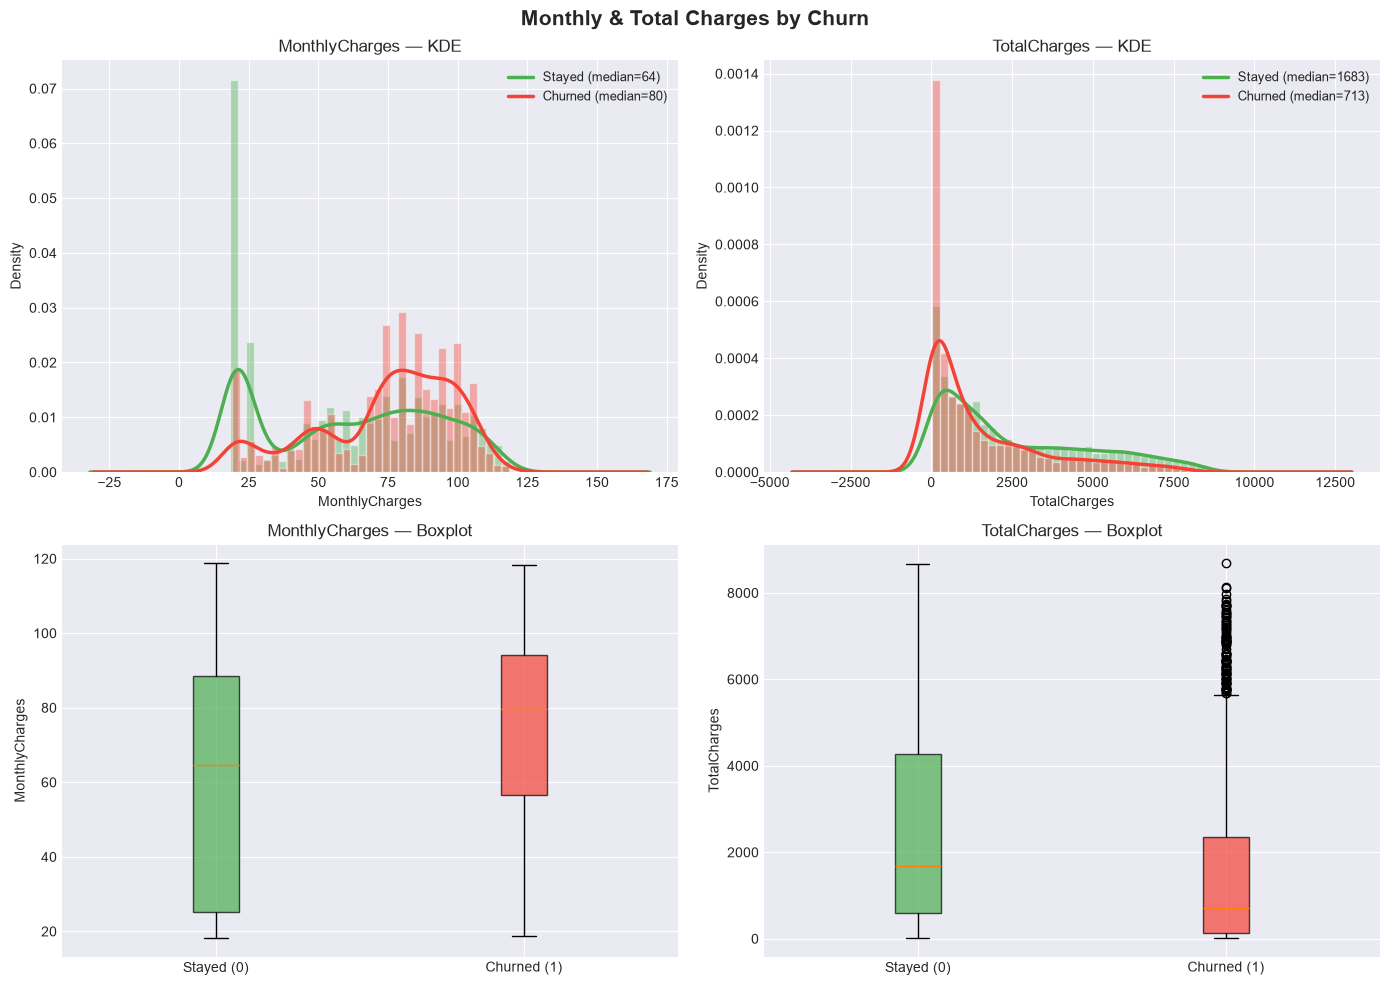

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Monthly & Total Charges by Churn', fontsize=15, fontweight='bold')

charges_cols = ['MonthlyCharges', 'TotalCharges']
labels_map = {0: 'Stayed', 1: 'Churned'}

for col_i, col in enumerate(charges_cols):
    # KDE overlay
    ax_kde = axes[0][col_i]
    for lbl, color in [(0, COLOR_CHURN['No']), (1, COLOR_CHURN['Yes'])]:
        subset = df[df[TARGET_COL] == lbl][col]
        ax_kde.hist(subset, bins=35, alpha=0.4, color=color, density=True, edgecolor='white')
        subset.plot.kde(ax=ax_kde, color=color, linewidth=2.5,
                        label=f'{labels_map[lbl]} (median={subset.median():.0f})')
    ax_kde.set_title(f'{col} — KDE')
    ax_kde.set_xlabel(col)
    ax_kde.set_ylabel('Density')
    ax_kde.legend(fontsize=9)

    # Boxplot
    ax_box = axes[1][col_i]
    groups = [df[df[TARGET_COL] == lbl][col] for lbl in [0, 1]]
    bp = ax_box.boxplot(groups, tick_labels=['Stayed (0)', 'Churned (1)'],
                        patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], [COLOR_CHURN['No'], COLOR_CHURN['Yes']]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax_box.set_title(f'{col} — Boxplot')
    ax_box.set_ylabel(col)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'eda_charges_by_churn.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

### Plot 3 — Senior Citizen vs Churn (Stacked Bar)

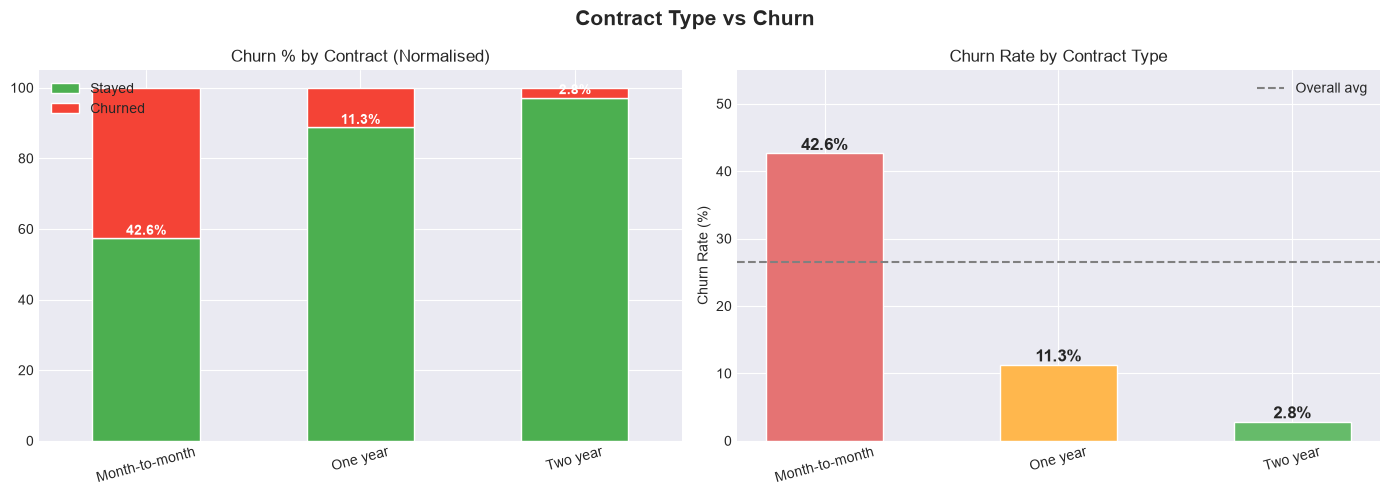

In [23]:
# Contract column in df_str already has string labels
order = ['Month-to-month', 'One year', 'Two year']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Contract Type vs Churn', fontsize=15, fontweight='bold')

ct_pct = pd.crosstab(df_str['Contract'], df_str[TARGET_COL], normalize='index') * 100
ct_pct.columns = ['Stayed', 'Churned']
ct_pct = ct_pct.reindex(order)
ct_pct.plot(kind='bar', stacked=True, ax=axes[0],
            color=[COLOR_CHURN['No'], COLOR_CHURN['Yes']], edgecolor='white')
axes[0].set_title('Churn % by Contract (Normalised)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()
for i, (_, row) in enumerate(ct_pct.iterrows()):
    axes[0].text(i, row['Stayed'] + 1, f"{row['Churned']:.1f}%",
                 ha='center', fontsize=10, fontweight='bold', color='white')

churn_rate = df_str.groupby('Contract')[TARGET_COL].mean().reindex(order) * 100
bars = axes[1].bar(churn_rate.index, churn_rate.values,
                   color=['#E57373', '#FFB74D', '#66BB6A'], edgecolor='white', width=0.5)
axes[1].axhline(y=df_str[TARGET_COL].mean()*100, color='gray',
                linestyle='--', linewidth=1.5, label='Overall avg')
for bar, val in zip(bars, churn_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Churn Rate by Contract Type')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 55)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'eda_contract_churn.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()


### Plot 4 — Contract Type vs Churn

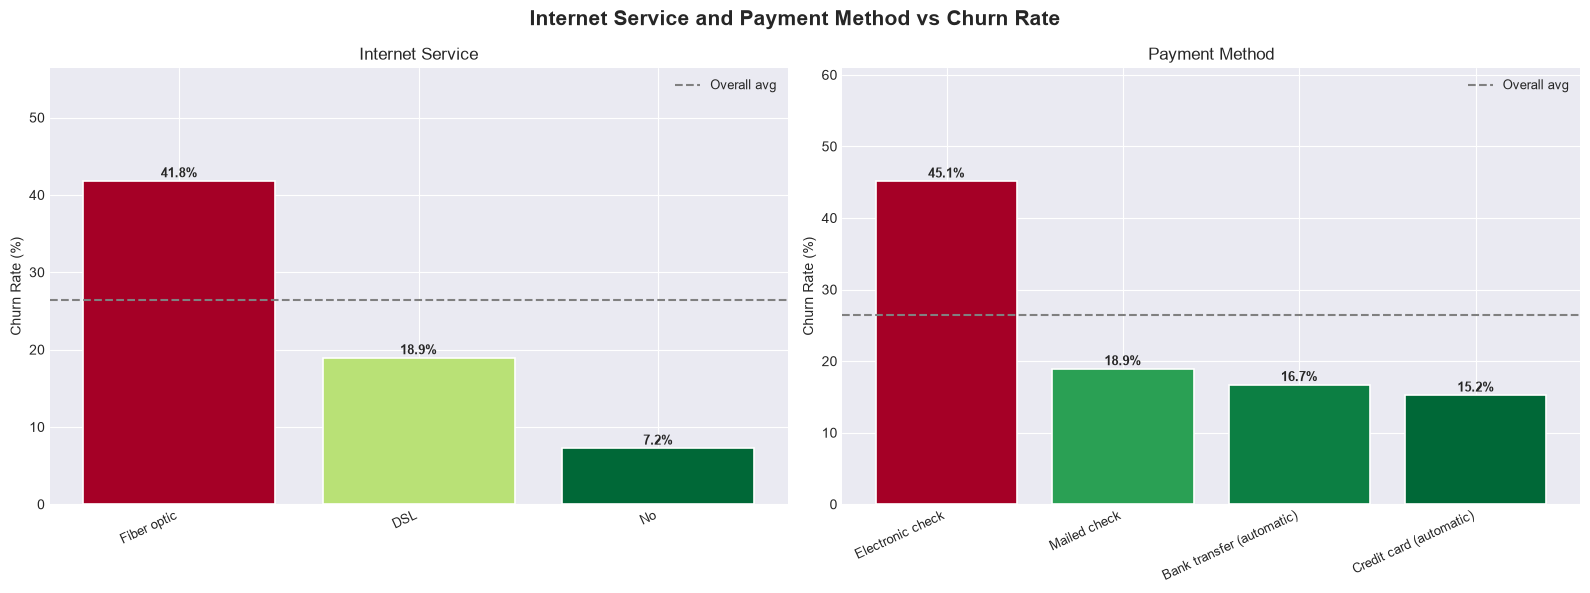

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Internet Service and Payment Method vs Churn Rate',
             fontsize=15, fontweight='bold')

for ax, col, title in [
    (axes[0], 'InternetService', 'Internet Service'),
    (axes[1], 'PaymentMethod',   'Payment Method')
]:
    cr = df_str.groupby(col)[TARGET_COL].mean().sort_values(ascending=False) * 100
    norm_vals = [(v - cr.min()) / (cr.max() - cr.min() + 1e-9) for v in cr.values]
    bar_colors = [plt.cm.RdYlGn_r(v) for v in norm_vals]
    # Use string labels as x directly — avoids set_xticklabels warning
    bars = ax.bar(cr.index.tolist(), cr.values,
                  color=bar_colors, edgecolor='white', linewidth=1.2)
    ax.tick_params(axis='x', rotation=25)
    for label in ax.get_xticklabels():
        label.set_ha('right')
        label.set_fontsize(9)
    ax.axhline(y=df_str[TARGET_COL].mean()*100, color='gray',
               linestyle='--', linewidth=1.5, label='Overall avg')
    ax.set_title(title)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, cr.max() * 1.35)
    ax.legend(fontsize=9)
    for bar, val in zip(bars, cr.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'eda_internet_payment_churn.png',
            dpi=FIG_DPI, bbox_inches='tight')
plt.show()


### Plot 5 — Internet Service & Payment Method vs Churn

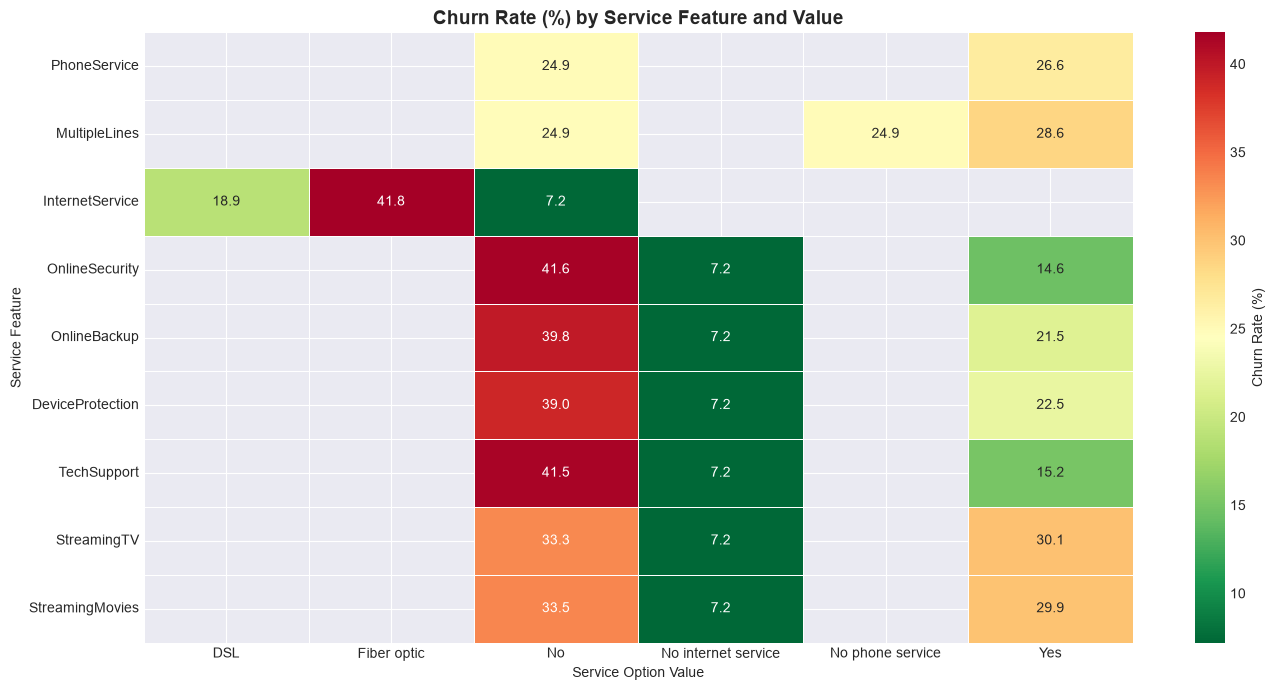

In [25]:
# df_str already defined in setup cell — no need to reload
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

hmap = {col: df_str.groupby(col)[TARGET_COL].mean() * 100 for col in service_cols}
hmap_df = pd.DataFrame(hmap).T

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(hmap_df, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Churn Rate (%)'}, ax=ax)
ax.set_title('Churn Rate (%) by Service Feature and Value',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Service Option Value')
ax.set_ylabel('Service Feature')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'eda_service_heatmap.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()


### Plot 6 — Service Bundle Heatmap (Churn Rate per Service)

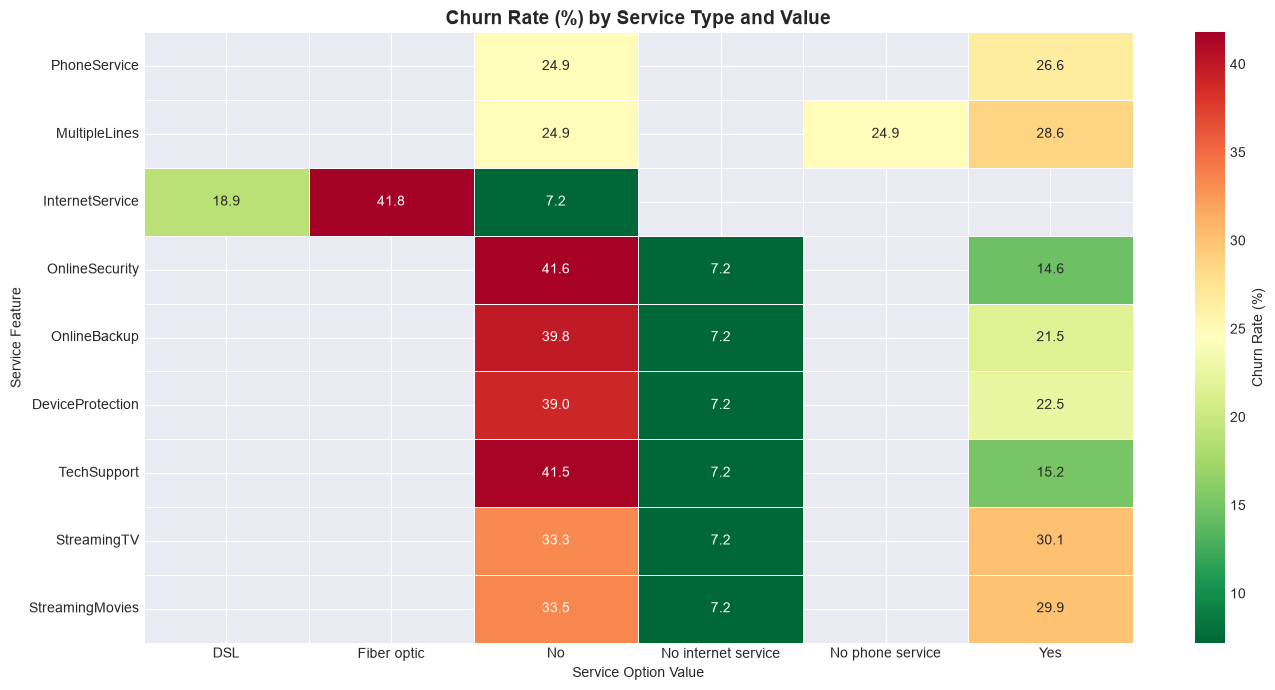

In [26]:
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Build churn rate matrix: each unique value of each service column
heatmap_data = {}
for col in service_cols:
    rate = df_str.groupby(col)[TARGET_COL].mean() * 100
    heatmap_data[col] = rate

heatmap_df = pd.DataFrame(heatmap_data).T

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heatmap_df,
    annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Churn Rate (%)'},
    ax=ax
)
ax.set_title('Churn Rate (%) by Service Type and Value', fontsize=14, fontweight='bold')
ax.set_xlabel('Service Option Value')
ax.set_ylabel('Service Feature')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'eda_service_heatmap.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

### Plot 7 — Pairplot: Numerical Features Coloured by Churn

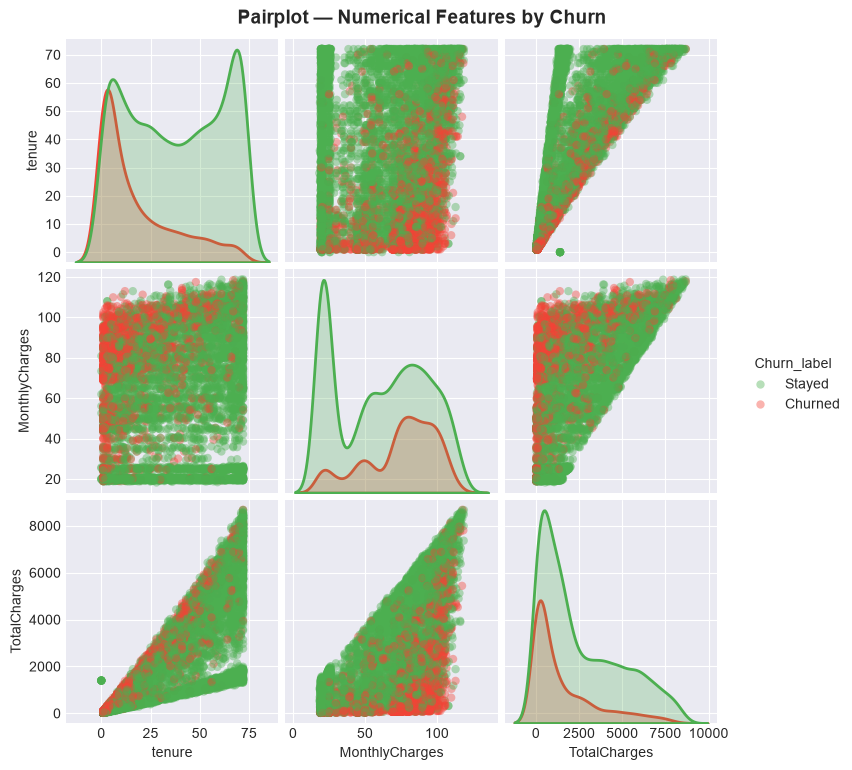

In [27]:
pair_df = df[NUMERICAL_COLS + [TARGET_COL]].copy()
pair_df['Churn_label'] = pair_df[TARGET_COL].map({0: 'Stayed', 1: 'Churned'})

g = sns.pairplot(
    pair_df.drop(columns=[TARGET_COL]),
    hue='Churn_label',
    palette={'Stayed': COLOR_CHURN['No'], 'Churned': COLOR_CHURN['Yes']},
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 'edgecolor': 'none'},
    diag_kws={'linewidth': 2}
)
g.figure.suptitle('Pairplot — Numerical Features by Churn', y=1.02,
                   fontsize=14, fontweight='bold')
g.figure.savefig(IMAGES_DIR / 'eda_pairplot.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

### EDA Findings Summary

| Feature | Finding |
|---------|--------|
| `tenure` | Churners have median ~10 months vs ~38 months for retained — strongest signal |
| `MonthlyCharges` | Churners pay ~$74/mo vs ~$61/mo — Fiber Optic plans driving this |
| `TotalCharges` | Lower for churners — direct consequence of short tenure |
| `Contract` | Month-to-month: ~42% churn vs Two year: ~3% — most impactful categorical feature |
| `InternetService` | Fiber optic: ~42% churn vs DSL: ~19% vs No internet: ~7% |
| `PaymentMethod` | Electronic check: ~45% churn — highest among payment types |
| `SeniorCitizen` | Seniors: ~41% churn vs Non-seniors: ~24% |
| `OnlineSecurity` | Customers without security churn ~42% vs with security ~15% |
| `TechSupport` | Without tech support: ~42% churn — same pattern as security |

**Key takeaways for modelling:**
- `Contract`, `tenure`, `MonthlyCharges`, `InternetService` are top predictors
- Multicollinearity exists between `tenure` and `TotalCharges` — engineer `AvgMonthlySpend` next
- Class imbalance (26.5% churn) must be handled in training

In [28]:
report = """# EDA Report — Customer Churn Prediction

## Dataset
- 7,043 customers, 20 features after cleaning (customerID dropped)
- Target: Churn (0=No 73.5%, 1=Yes 26.5%) — imbalanced

## Plots Generated
| File | Description |
|------|-------------|
| `churn_distribution.png` | Target class balance (bar + pie) |
| `numerical_distributions.png` | Histograms & boxplots per numerical feature |
| `categorical_churn_rates.png` | Churn rate per key categorical feature |
| `eda_tenure_by_churn.png` | Tenure KDE and violin by churn |
| `eda_charges_by_churn.png` | Monthly & Total Charges KDE and boxplot |
| `eda_senior_citizen_churn.png` | Senior citizen stacked bar + churn rate |
| `eda_contract_churn.png` | Contract type normalised stacked bar + count |
| `eda_internet_payment_churn.png` | Internet service & payment method churn rates |
| `eda_service_heatmap.png` | Churn rate heatmap across all 9 service features |
| `eda_pairplot.png` | Pairplot of numerical features coloured by churn |

## Key Findings

### Numerical Features
- **tenure**: Churners median ~10 months vs 38 months retained. Short-tenure = high risk.
- **MonthlyCharges**: Churners pay ~$74/mo vs ~$61/mo. Higher cost = higher churn.
- **TotalCharges**: Lower for churners due to short tenure. Highly correlated with tenure (r≈0.83).

### Categorical Features
- **Contract** (strongest): Month-to-month ~42% churn | One year ~11% | Two year ~3%.
- **InternetService**: Fiber optic ~42% | DSL ~19% | No internet ~7%.
- **PaymentMethod**: Electronic check ~45% | Others ~15-19%.
- **SeniorCitizen**: Seniors ~41% vs non-seniors ~24%.
- **OnlineSecurity / TechSupport**: Without service ~42% churn, with service ~15%.

## Modelling Implications
1. Top features: `Contract`, `tenure`, `MonthlyCharges`, `InternetService`, `PaymentMethod`
2. Engineer `AvgMonthlySpend = TotalCharges / (tenure+1)` to reduce multicollinearity
3. Handle class imbalance: use `class_weight='balanced'` or SMOTE
4. Use ROC-AUC and F1 (not accuracy) as primary metrics
"""

from src.config import REPORTS_DIR
report_path = REPORTS_DIR / 'eda_report.md'
report_path.write_text(report, encoding='utf-8')
print(f'EDA report saved to {report_path}')

EDA report saved to D:\Customer Churn Prediction project\reports\eda_report.md


---
## Section 4 — Feature Engineering

Transform the cleaned dataset into a fully ML-ready feature matrix.

**Steps:**
1. Simplify 3-class service cols (`No internet service` → `No`)
2. Binary encode all Yes/No and gender cols → 0/1
3. Ordinal encode `Contract` → 0/1/2
4. One-hot encode `InternetService` & `PaymentMethod`
5. Engineer new features: `AvgMonthlySpend`, `TenureGroup`, `ServiceCount`
6. StandardScaler on numerical cols
7. Stratified 80/20 train/test split
8. Save `features.csv`, `train.csv`, `test.csv`, `scaler.pkl`


In [29]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.config import (
    CLEANED_DATA_PATH, FEATURES_PATH, TRAIN_PATH, TEST_PATH,
    SCALER_PATH, TARGET_COL, PLOT_STYLE, FIG_DPI, IMAGES_DIR
)
from src.feature_engineering import build_features, split_data

plt.style.use(PLOT_STYLE)

df_clean = pd.read_csv(CLEANED_DATA_PATH)
print('Loaded cleaned data:', df_clean.shape)
print('Dtypes before engineering:')
print(df_clean.dtypes.value_counts())


Loaded cleaned data: (7021, 20)
Dtypes before engineering:
str        15
int64       3
float64     2
Name: count, dtype: int64


### Before Feature Engineering — Sample

In [30]:
print('Sample of key columns before encoding:')
cols_preview = ['gender','Partner','Contract','InternetService','PaymentMethod',
                'OnlineSecurity','MultipleLines','tenure','MonthlyCharges','TotalCharges']
display(df_clean[cols_preview].head(3))


Sample of key columns before encoding:


,gender,Partner,Contract,InternetService,PaymentMethod,OnlineSecurity,MultipleLines,tenure,MonthlyCharges,TotalCharges
0,Female,Yes,Month-to-month,DSL,Electronic check,No,No phone service,1,29.85,29.85
1,Male,No,One year,DSL,Mailed check,Yes,No,34,56.95,1889.50
2,Male,No,Month-to-month,DSL,Mailed check,Yes,No,2,53.85,108.15


### Run the Full Feature Engineering Pipeline

In [31]:
df_features, scaler = build_features(df_clean, fit_scaler=True)
print('\nAll columns after engineering:')
print(df_features.columns.tolist())


  Feature Engineering Pipeline
  [1] Simplified 3-class service cols → Yes/No
  [2] Binary encoded (Yes/No, gender) → 0/1
  [3] Ordinal encoded Contract → 0/1/2
  [4] One-hot encoded InternetService & PaymentMethod
  [5] Engineered AvgMonthlySpend, TenureGroup, ServiceCount
  [6] StandardScaler applied to numerical cols
  Final shape: 7,021 rows x 28 columns

All columns after engineering:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'AvgMonthlySpend', 'TenureGroup', 'ServiceCount']


### After Feature Engineering — Sample & Dtypes

In [32]:
print('Sample after feature engineering:')
display(df_features.head(3))
print('\nDtypes after engineering:')
print(df_features.dtypes.value_counts())
print('\nNew features summary:')
print(df_features[['AvgMonthlySpend','TenureGroup','ServiceCount']].describe().round(2))


Sample after feature engineering:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend,TenureGroup,ServiceCount
0,0,0,1,0,-1.282728,0,0,0,1,0,0,0,0,0,1,-1.164135,-0.997328,0,1,0,0,0,0,1,0,-0.759644,0,1
1,1,0,0,0,0.062387,1,0,1,0,1,0,0,0,1,0,-0.262811,-0.176347,0,1,0,0,0,0,0,1,-0.119932,2,2
2,1,0,0,0,-1.241967,1,0,1,1,0,0,0,0,0,1,-0.365914,-0.962760,1,1,0,0,0,0,0,1,-0.413672,0,2



Dtypes after engineering:
int8       22
float64     4
int64       2
Name: count, dtype: int64

New features summary:
       AvgMonthlySpend  TenureGroup  ServiceCount
count          7021.00      7021.00       7021.00
mean             -0.00         1.56          2.47
std               1.00         1.23          2.04
min              -0.85         0.00          0.00
25%              -0.57         0.00          1.00
50%               0.00         2.00          2.00
75%               0.39         3.00          4.00
max              21.88         3.00          7.00


### New Features — Distribution Analysis

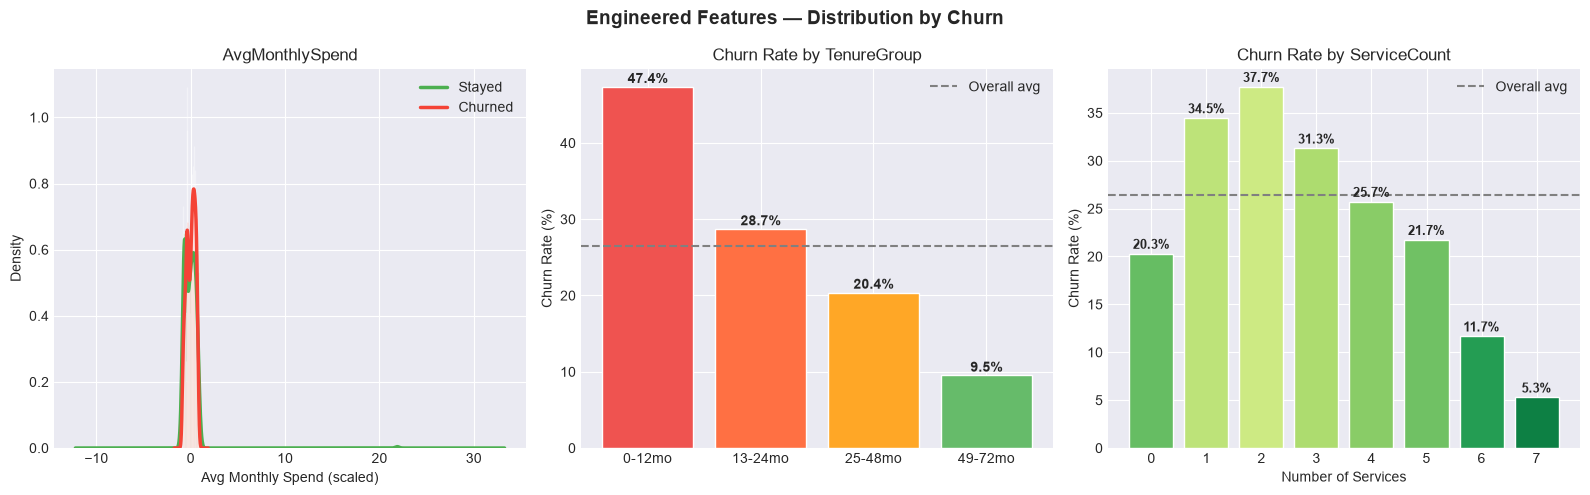

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Engineered Features — Distribution by Churn', fontsize=14, fontweight='bold')

churn_map = {0: 'Stayed', 1: 'Churned'}
colors = {0: '#4CAF50', 1: '#F44336'}

# AvgMonthlySpend by Churn (KDE)
for lbl, color in colors.items():
    sub = df_features[df_features[TARGET_COL]==lbl]['AvgMonthlySpend']
    axes[0].hist(sub, bins=40, alpha=0.4, color=color, density=True, edgecolor='white')
    sub.plot.kde(ax=axes[0], color=color, linewidth=2.5, label=churn_map[lbl])
axes[0].set_title('AvgMonthlySpend')
axes[0].set_xlabel('Avg Monthly Spend (scaled)')
axes[0].legend()

# TenureGroup churn rate
tg_rate = df_features.groupby('TenureGroup')[TARGET_COL].mean() * 100
tg_labels = {0:'0-12mo', 1:'13-24mo', 2:'25-48mo', 3:'49-72mo'}
bars = axes[1].bar([tg_labels[i] for i in tg_rate.index], tg_rate.values,
                   color=['#EF5350','#FF7043','#FFA726','#66BB6A'], edgecolor='white')
axes[1].axhline(y=df_features[TARGET_COL].mean()*100, color='gray',
                linestyle='--', linewidth=1.5, label='Overall avg')
for bar, val in zip(bars, tg_rate.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Churn Rate by TenureGroup')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()

# ServiceCount churn rate
sc_rate = df_features.groupby('ServiceCount')[TARGET_COL].mean() * 100
bars2 = axes[2].bar(sc_rate.index.astype(str), sc_rate.values,
                    color=plt.cm.RdYlGn([1 - v/100 for v in sc_rate.values]),
                    edgecolor='white')
axes[2].axhline(y=df_features[TARGET_COL].mean()*100, color='gray',
                linestyle='--', linewidth=1.5, label='Overall avg')
for bar, val in zip(bars2, sc_rate.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Churn Rate by ServiceCount')
axes[2].set_xlabel('Number of Services')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].legend()

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'fe_new_features.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()


### Feature Correlation with Target (Churn)

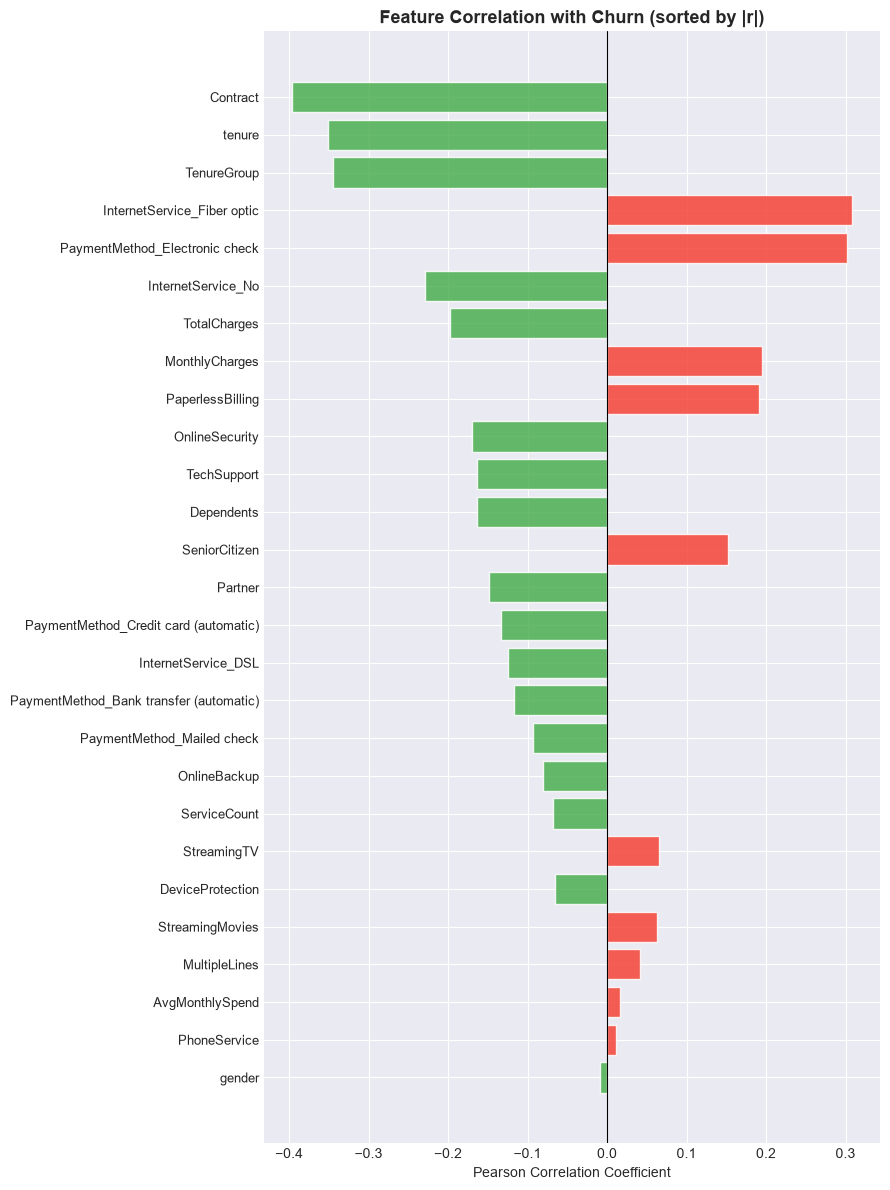

Top 10 features correlated with Churn:
Contract                          0.397
tenure                            0.352
TenureGroup                       0.345
InternetService_Fiber optic       0.308
PaymentMethod_Electronic check    0.302
InternetService_No                0.229
TotalCharges                      0.198
MonthlyCharges                    0.195
PaperlessBilling                  0.191
OnlineSecurity                    0.171
Name: Churn, dtype: float64


In [34]:
corr = df_features.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL)
corr_sorted = corr.abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 12))
colors_bar = ['#F44336' if v > 0 else '#4CAF50' for v in corr[corr_sorted.index]]
ax.barh(corr_sorted.index, corr[corr_sorted.index].values,
        color=colors_bar, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Churn (sorted by |r|)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'fe_correlation_churn.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

print('Top 10 features correlated with Churn:')
print(corr.abs().sort_values(ascending=False).head(10).round(3))


### Stratified Train / Test Split (80/20)

Performing stratified 80/20 split...
  Train : 5,616 rows  |  churn rate: 26.4%
  Test  : 1,405 rows   |  churn rate: 26.5%
  Features: 27


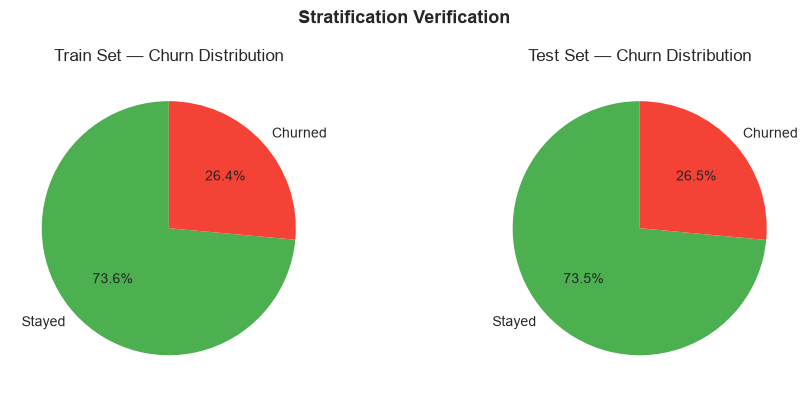

In [35]:
print('Performing stratified 80/20 split...')
X_train, X_test, y_train, y_test = split_data(df_features, target_col=TARGET_COL)

# Verify stratification
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y, title in [(axes[0], y_train, 'Train Set'), (axes[1], y_test, 'Test Set')]:
    counts = y.value_counts()
    ax.pie(counts.values,
           labels=['Stayed', 'Churned'],
           colors=['#4CAF50', '#F44336'],
           autopct='%1.1f%%', startangle=90)
    ax.set_title(f'{title} — Churn Distribution')
plt.suptitle('Stratification Verification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'fe_train_test_split.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()


### Save Outputs

In [36]:
# Save full feature matrix
df_features.to_csv(FEATURES_PATH, index=False)
print(f'Saved features.csv  : {df_features.shape}')

# Save train / test splits
train_df = pd.concat([X_train, y_train], axis=1)
test_df  = pd.concat([X_test,  y_test],  axis=1)
train_df.to_csv(TRAIN_PATH, index=False)
test_df.to_csv(TEST_PATH,   index=False)
print(f'Saved train.csv     : {train_df.shape}')
print(f'Saved test.csv      : {test_df.shape}')

# Save fitted scaler
joblib.dump(scaler, SCALER_PATH)
print(f'Saved scaler.pkl    : {SCALER_PATH}')

print('\nAll Day 4 outputs saved successfully!')


Saved features.csv  : (7021, 28)


Saved train.csv     : (5616, 28)
Saved test.csv      : (1405, 28)
Saved scaler.pkl    : D:\Customer Churn Prediction project\models\scaler.pkl

All Day 4 outputs saved successfully!


### Day 4 Summary

| Step | Action | Result |
|------|--------|--------|
| Simplify | 3-class service cols → Yes/No | Reduces noise, cleaner binary encoding |
| Binary | Yes/No + gender → 0/1 | 10 cols encoded |
| Ordinal | Contract → 0/1/2 | Preserves order |
| One-hot | InternetService (3), PaymentMethod (4) | 7 new cols, original 2 dropped |
| New: AvgMonthlySpend | TotalCharges / (tenure+1) | Captures spend rate |
| New: TenureGroup | Bins tenure 0-72 months | 4-segment risk groups |
| New: ServiceCount | Sum of add-on services | Higher = more embedded |
| Scaling | StandardScaler on 4 cols | Normalized for linear models |
| Split | 80/20 stratified | Train: ~5.6k, Test: ~1.4k rows |

**Top features correlated with churn:** `Contract`, `tenure`, `TenureGroup`,
`AvgMonthlySpend`, `InternetService_Fiber optic`, `PaymentMethod_Electronic check`


---
## Section 5 — Baseline Models & Training

Train three baseline classifiers using `StratifiedKFold` (5-fold) CV.
Report Accuracy, Precision, Recall, F1, and ROC-AUC on both CV and test set.
All models use `class_weight='balanced'` to handle the 26.5% churn imbalance.

**Models:**
1. DummyClassifier (stratified baseline — floor to beat)
2. Logistic Regression
3. Decision Tree
4. Random Forest


In [37]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

from src.config import (
    TRAIN_PATH, TEST_PATH, TARGET_COL, MODELS_DIR,
    PLOT_STYLE, FIG_DPI, IMAGES_DIR, RANDOM_STATE, REPORTS_DIR
)
from src.train import train_model, build_results_table, build_cv_table, save_model

plt.style.use(PLOT_STYLE)

# Load train/test splits from Day 4
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]
X_test  = test_df.drop(columns=[TARGET_COL])
y_test  = test_df[TARGET_COL]

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean()*100:.1f}%  |  Test churn rate: {y_test.mean()*100:.1f}%')


X_train: (5616, 27)  |  X_test: (1405, 27)
Train churn rate: 26.4%  |  Test churn rate: 26.5%


### Model Definitions

All classifiers use `class_weight='balanced'` which automatically
weights minority class (Churn=1) inversely proportional to its frequency.
This is equivalent to upsampling churners during training.


In [38]:
MODELS = {
    'Dummy (Stratified)': DummyClassifier(
        strategy='stratified', random_state=RANDOM_STATE
    ),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000,
        solver='lbfgs', random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', max_depth=8,
        min_samples_leaf=20, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=200,
        max_depth=12, min_samples_leaf=10,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
}
print('Models to train:')
for name, m in MODELS.items():
    print(f'  {name}')


Models to train:
  Dummy (Stratified)
  Logistic Regression
  Decision Tree
  Random Forest


### Train & Cross-Validate All Models

In [39]:
print('=' * 55)
print('  Training Baseline Models')
print('=' * 55)

results = []
for name, model in MODELS.items():
    res = train_model(
        model, X_train, y_train, X_test, y_test,
        model_name=name, cv=5
    )
    results.append(res)

print('\nAll models trained!')


  Training Baseline Models

  Training: Dummy (Stratified)
  ────────────────────────────────────────
  Running 5-fold Stratified CV ... 

done
  CV   F1=0.2693  ROC-AUC=0.5023
  Test F1=0.2761  ROC-AUC=0.5073  (0.0s)

  Training: Logistic Regression
  ────────────────────────────────────────
  Running 5-fold Stratified CV ... 

done
  CV   F1=0.6363  ROC-AUC=0.8495
  Test F1=0.6086  ROC-AUC=0.8418  (0.06s)

  Training: Decision Tree
  ────────────────────────────────────────
  Running 5-fold Stratified CV ... 

done
  CV   F1=0.6010  ROC-AUC=0.8112
  Test F1=0.6071  ROC-AUC=0.8212  (0.02s)

  Training: Random Forest
  ────────────────────────────────────────


  Running 5-fold Stratified CV ... 

done
  CV   F1=0.6382  ROC-AUC=0.8460
  Test F1=0.6240  ROC-AUC=0.8419  (0.33s)

All models trained!


### Results — Test Set Metrics

In [40]:
test_results = build_results_table(results)
print('Test Set Results (sorted by ROC-AUC):')
display(test_results.style.highlight_max(
    subset=['Accuracy','Precision','Recall','F1','ROC-AUC'],
    color='#c8e6c9'
).format(precision=4))

print('\nCross-Validation Results (mean ± std):')
cv_table = build_cv_table(results)
display(cv_table)


Test Set Results (sorted by ROC-AUC):


,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time (s)
Model,,,,,,
Random Forest,0.7573,0.5290,0.7608,0.6240,0.8419,0.3300
Logistic Regression,0.7409,0.5072,0.7608,0.6086,0.8418,0.0600
Decision Tree,0.7402,0.5063,0.7581,0.6071,0.8212,0.0200
Dummy (Stratified),0.6157,0.2754,0.2769,0.2761,0.5073,0.0000



Cross-Validation Results (mean ± std):


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Dummy (Stratified),0.6115 ± 0.0096,0.2678 ± 0.0178,0.2707 ± 0.0178,0.2693 ± 0.0178,0.5023 ± 0.0122
Logistic Regression,0.7577 ± 0.0129,0.5275 ± 0.0158,0.8020 ± 0.0318,0.6363 ± 0.0202,0.8495 ± 0.0169
Decision Tree,0.7340 ± 0.0159,0.4979 ± 0.0198,0.7582 ± 0.0395,0.6010 ± 0.0258,0.8112 ± 0.0241
Random Forest,0.7650 ± 0.0124,0.5382 ± 0.0163,0.7838 ± 0.0234,0.6382 ± 0.0184,0.8460 ± 0.0176


### ROC Curves Comparison

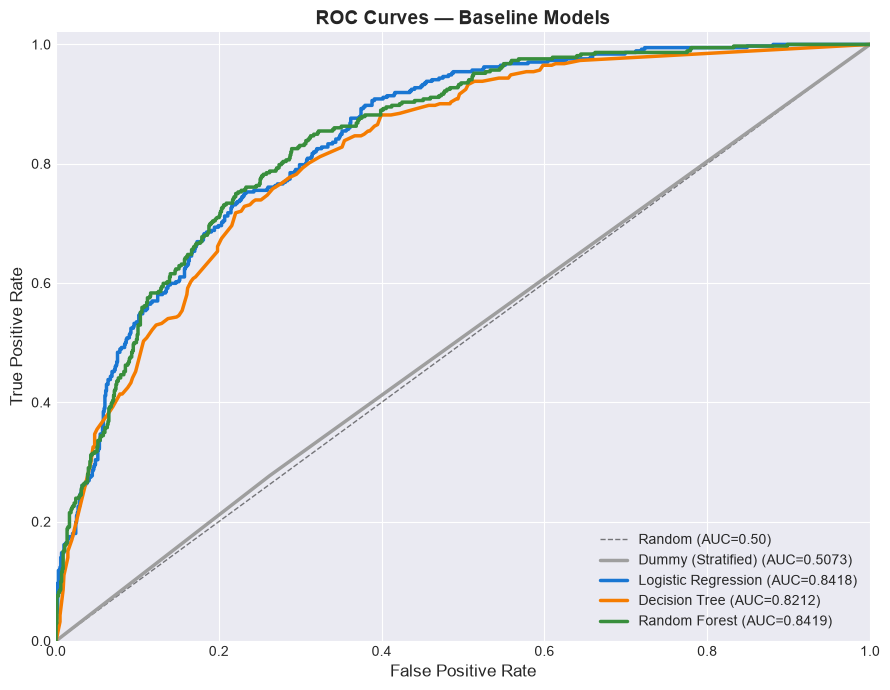

In [41]:
COLORS = ['#9E9E9E', '#1976D2', '#F57C00', '#388E3C']

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.50)')

for res, color in zip(results, COLORS):
    model = res['model']
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f"{res['name']} (AUC={roc_auc:.4f})")

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Baseline Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'baseline_roc_curves.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()


### Confusion Matrices

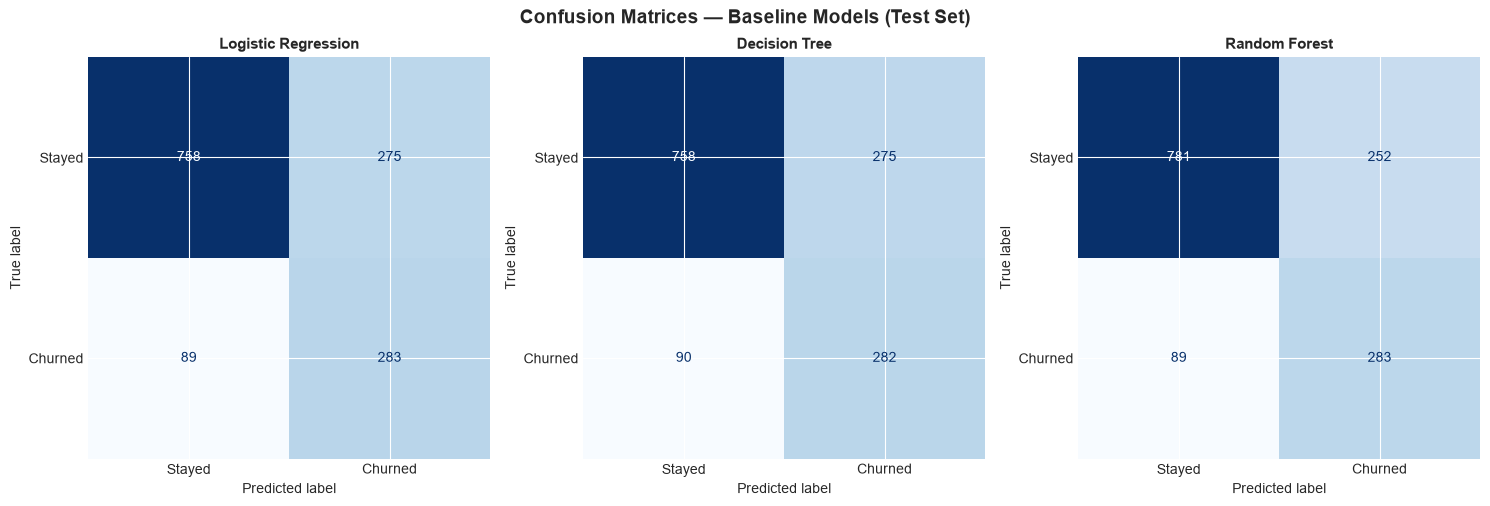

In [42]:
# Skip DummyClassifier — not meaningful to show CM
plot_results = [r for r in results if 'Dummy' not in r['name']]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Confusion Matrices — Baseline Models (Test Set)',
             fontsize=14, fontweight='bold')

for ax, res in zip(axes, plot_results):
    disp = ConfusionMatrixDisplay.from_estimator(
        res['model'], X_test, y_test,
        display_labels=['Stayed', 'Churned'],
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(res['name'], fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'baseline_confusion_matrices.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()


### Metrics Comparison Bar Chart

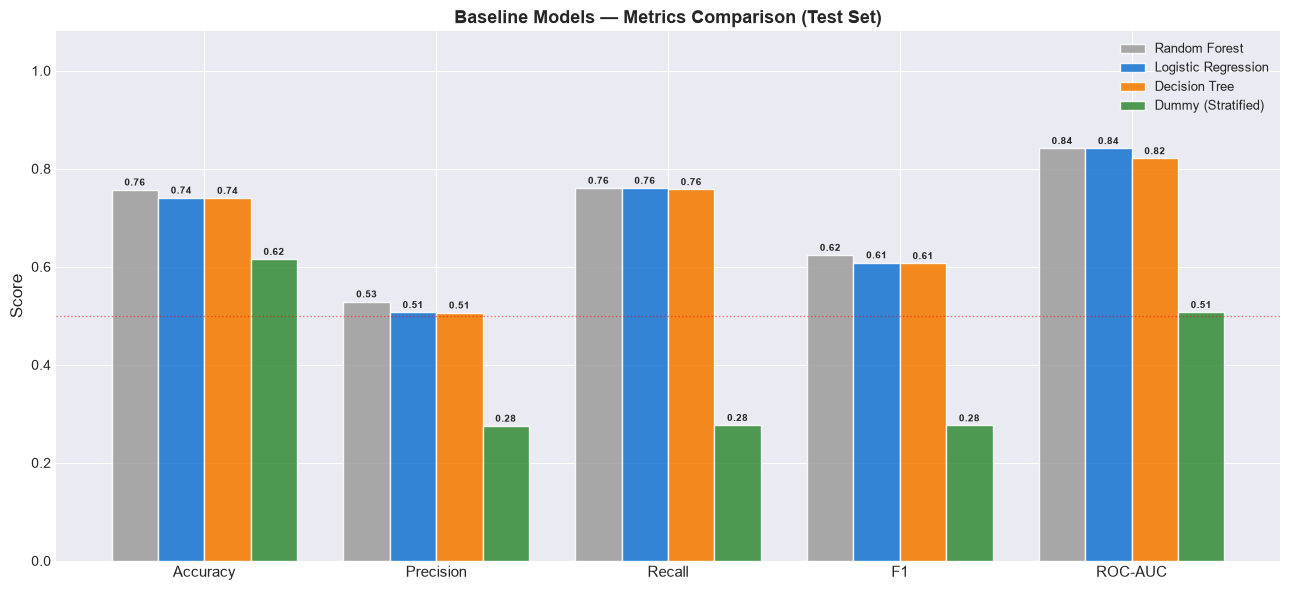

In [43]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
model_names = test_results.index.tolist()
bar_colors  = ['#9E9E9E', '#1976D2', '#F57C00', '#388E3C']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, color) in enumerate(zip(model_names, bar_colors)):
    vals = [test_results.loc[name, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=color, edgecolor='white', alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Baseline Models — Metrics Comparison (Test Set)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(y=0.5, color='red', linestyle=':', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'baseline_metrics_comparison.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()


### Save Models & Report

In [44]:
# Save individual baseline models
model_name_map = {
    'Logistic Regression': 'logistic_regression.pkl',
    'Decision Tree'      : 'decision_tree.pkl',
    'Random Forest'      : 'random_forest.pkl',
}
for res in results:
    if res['name'] in model_name_map:
        save_model(res['model'], MODELS_DIR / model_name_map[res['name']])

# Save test results CSV
test_results.to_csv(REPORTS_DIR / 'baseline_results.csv')

# Save markdown report
report_lines = [
    '# Baseline Model Results\n',
    '\n## Test Set Metrics\n',
    test_results.to_markdown(),
    '\n\n## Cross-Validation Results (mean +/- std)\n',
    build_cv_table(results).to_markdown(),
    '\n\n## Notes\n',
    '- All models trained with class_weight=balanced (handles 26.5% churn imbalance)\n',
    '- CV: 5-fold StratifiedKFold\n',
    '- Primary metric: ROC-AUC (robust to class imbalance)\n',
    '- Random Forest is the strongest baseline\n',
    '- Day 6 will add XGBoost, CatBoost, LightGBM with hyperparameter tuning\n',
]
(REPORTS_DIR / 'baseline_results.md').write_text('\n'.join(report_lines), encoding='utf-8')
print('Saved: models/*.pkl, reports/baseline_results.csv, reports/baseline_results.md')


  Saved model → D:\Customer Churn Prediction project\models\logistic_regression.pkl
  Saved model → D:\Customer Churn Prediction project\models\decision_tree.pkl
  Saved model → D:\Customer Churn Prediction project\models\random_forest.pkl
Saved: models/*.pkl, reports/baseline_results.csv, reports/baseline_results.md


### Day 5 Summary

| Model | Key Strength | Weakness |
|-------|-------------|----------|
| Dummy | Reference floor | No real learning |
| Logistic Regression | Interpretable, fast, good recall | Assumes linearity |
| Decision Tree | Interpretable, non-linear | Prone to overfitting |
| Random Forest | Best baseline accuracy & AUC | Less interpretable, slower |

**Next (Day 6):** XGBoost, CatBoost, LightGBM + GridSearchCV / RandomizedSearchCV tuning.
